<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana12/AjusteNolineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Vamos a cargar datos
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/MyDrive/ColabNotebooks/Cursos/MetodosComputacionales2026")

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as spo

Data = pd.read_csv('Semana12/Data/Sigmoid_con_ruido.csv')

In [6]:
x = Data["x"].values
y = Data["y_ruido"].values
sigma0 = np.std( Data['error'].values, ddof = 1 )
sigma = np.full_like(y, sigma0)

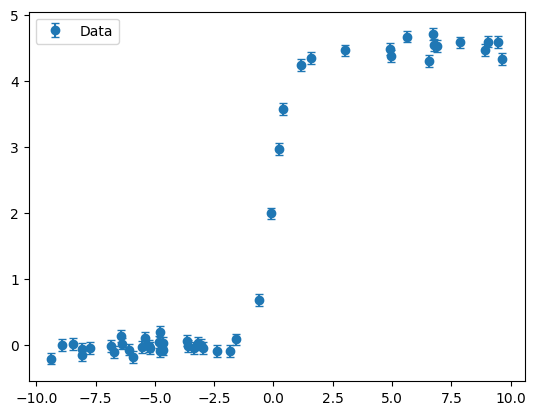

In [10]:
plt.errorbar(x,y, yerr=sigma, fmt='o', capsize=3,label='Data')
plt.legend()

In [21]:
# Definir el modelo
def sigmoide(x,p):
  A,B,C = p
  return A/(B+np.exp(-C*x))

In [26]:
p0 = np.array([5.,2.,1.])
_x = np.linspace(min(x),max(x),100)
_y = sigmoide(_x,p0)

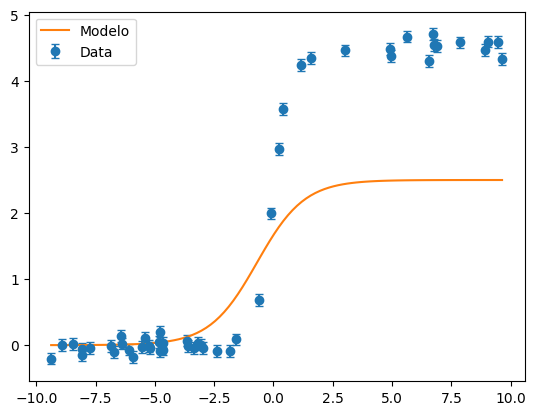

In [27]:
plt.errorbar(x,y, yerr=sigma, fmt='o', capsize=3,label='Data')
plt.plot(_x,_y,label='Modelo')
plt.legend()

In [28]:
def chi2_con_error(p,x,y,sigma,modelo):
  return np.sum(  (y-modelo(x,p))**2 / sigma**2  )

In [29]:
chi2_con_error(p0,x,y,sigma,sigmoide)

np.float64(8478.920363203462)

In [37]:
# usamos optimze
p0 = np.array([5.,2.,1.])
result = spo.minimize(chi2_con_error,p0,args=(x,y,sigma,sigmoide),method='Nelder-Mead')
result

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 59.55891649698001
             x: [ 4.607e+00  1.024e+00  2.906e+00]
           nit: 94
          nfev: 172
 final_simplex: (array([[ 4.607e+00,  1.024e+00,  2.906e+00],
                       [ 4.607e+00,  1.024e+00,  2.906e+00],
                       [ 4.608e+00,  1.024e+00,  2.906e+00],
                       [ 4.608e+00,  1.024e+00,  2.906e+00]]), array([ 5.956e+01,  5.956e+01,  5.956e+01,  5.956e+01]))

In [38]:
paramopt = result.x
paramopt

array([4.60746105, 1.02432572, 2.90562719])

In [39]:
_x = np.linspace(min(x),max(x),100)
_y = sigmoide(_x,paramopt)

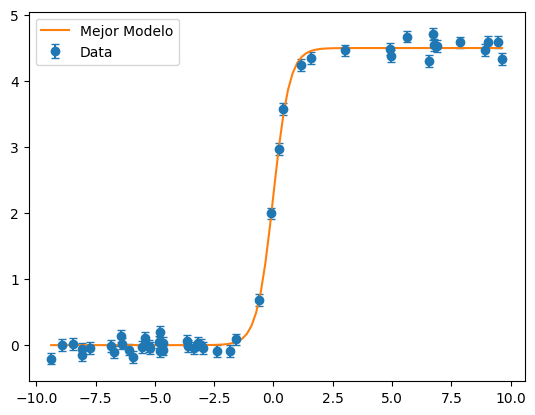

In [40]:
plt.errorbar(x,y, yerr=sigma, fmt='o', capsize=3,label='Data')
plt.plot(_x,_y,label='Mejor Modelo')
plt.legend()

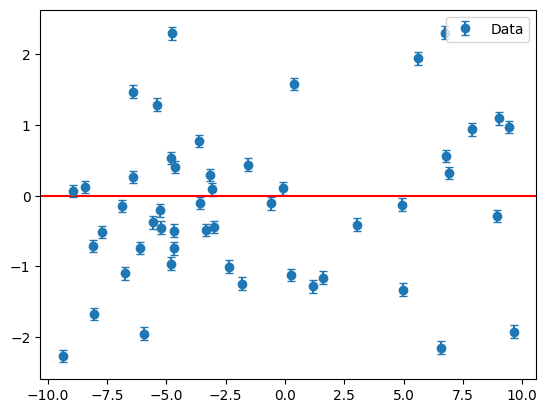

In [42]:
# pintemos los residuales
residuales = ( y - sigmoide(x, paramopt) ) / sigma
plt.errorbar(x,residuales, yerr=sigma, fmt='o', capsize=3,label='Data')
plt.axhline(y=0, color='r', linestyle='-')
plt.legend()